# BÁO CÁO THỰC HÀNH: DỰ ĐOÁN NGUY CƠ TIỂU ĐƯỜNG

## 1. Giới thiệu
Tiểu đường (Diabetes) là một trong những bệnh mãn tính phổ biến nhất. Việc phát hiện sớm nguy cơ dựa trên các chỉ số sức khỏe (như đường huyết, chỉ số BMI, tiền sử bệnh tim...) có ý nghĩa quan trọng trong y học dự phòng.

Trong bài thực hành này, chúng ta sẽ làm việc với một tập dữ liệu y tế lớn (**100.000 hồ sơ**) để xây dựng mô hình dự báo xem một bệnh nhân có bị tiểu đường hay không.

## 2. Mục tiêu
* **Xử lý dữ liệu lớn:** Làm sạch và chuẩn hóa dữ liệu y tế.
* **Mô hình hóa:** So sánh hiệu quả của `Decision Tree` và `Random Forest`.
* **Phân tích y học:** Tìm ra đâu là những "kẻ giết người thầm lặng" (các chỉ số nguy hiểm nhất) thông qua Feature Importance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

# Cấu hình hiển thị
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
import warnings
warnings.filterwarnings('ignore')

## 3. Đọc và Khám phá dữ liệu
Tập dữ liệu `diabetes_prediction_dataset.csv` bao gồm các đặc trưng:
* **Thông tin cá nhân:** `gender` (Giới tính), `age` (Tuổi), `smoking_history` (Lịch sử hút thuốc).
* **Chỉ số sức khỏe:** `bmi` (Chỉ số khối cơ thể), `hypertension` (Cao huyết áp), `heart_disease` (Bệnh tim).
* **Xét nghiệm máu:** `HbA1c_level` (Đường huyết trung bình 3 tháng), `blood_glucose_level` (Đường huyết hiện tại).

In [2]:
# Đọc dữ liệu
df = pd.read_csv('diabetes_prediction_dataset.csv')

# Hiển thị thông tin
print("Kích thước dữ liệu:", df.shape)
print("-" * 30)
df.info()

# Kiểm tra phân bố nhãn (Bệnh vs Không bệnh)
print("\nPhân bố nhãn (Diabetes):")
print(df['diabetes'].value_counts())

# Xem thử 5 dòng đầu
display(df.head())

Kích thước dữ liệu: (100000, 9)
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB

Phân bố nhãn (Diabetes):
diabetes
0    91500
1     8500
Name: count, dtype: int64


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


**Nhận xét dữ liệu:**
1.  **Mất cân bằng dữ liệu (Imbalanced Data):** Số lượng người khỏe mạnh (0) áp đảo số lượng người bệnh (1). Tỷ lệ khoảng 9:1. Điều này cảnh báo rằng chỉ số Accuracy có thể gây hiểu lầm (nếu đoán toàn bộ là "Khỏe" thì vẫn đúng 90%).
2.  **Dữ liệu phân loại:** Cột `gender` và `smoking_history` là dạng chữ, cần được mã hóa.
3.  **Dữ liệu sạch:** Không có giá trị thiếu (NaN) trong tập này, nhưng cần kiểm tra kỹ các giá trị lạ (ví dụ: 'No Info' trong lịch sử hút thuốc).

## 4. Tiền xử lý dữ liệu (Preprocessing)
Chúng ta sẽ thực hiện:
1.  **Mã hóa (Encoding):** Chuyển `gender` và `smoking_history` sang số.
2.  **Chuẩn hóa:** Với các thuật toán cây (Tree-based), việc chuẩn hóa (Scaling) dữ liệu không bắt buộc, nhưng việc mã hóa là bắt buộc.

In [3]:
def preprocess_diabetes(df):
    df_clean = df.copy()
    
    # 1. Mã hóa giới tính
    # Kiểm tra xem có giới tính 'Other' không
    print("Các loại giới tính trước xử lý:", df_clean['gender'].unique())
    # Có thể giữ 'Other' hoặc gán nó vào nhóm đa số. Ở đây ta dùng LabelEncoder đơn giản.
    le_gen = LabelEncoder()
    df_clean['gender'] = le_gen.fit_transform(df_clean['gender'])
    
    # 2. Mã hóa lịch sử hút thuốc
    # 'No Info' cũng là một thông tin quan trọng, ta sẽ giữ nguyên nó như một category riêng
    le_smoke = LabelEncoder()
    df_clean['smoking_history'] = le_smoke.fit_transform(df_clean['smoking_history'])
    
    return df_clean

# Áp dụng
df_processed = preprocess_diabetes(df)

# Tách Features và Target
X = df_processed.drop('diabetes', axis=1)
y = df_processed['diabetes']

# Chia tập dữ liệu (80% Train, 20% Test)
# Stratify=y để đảm bảo tỷ lệ người bệnh trong tập train và test là như nhau
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nKích thước tập Train:", X_train.shape)
print("Kích thước tập Test:", X_test.shape)
display(X_train.head())

Các loại giới tính trước xử lý: ['Female' 'Male' 'Other']

Kích thước tập Train: (80000, 8)
Kích thước tập Test: (20000, 8)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
74736,0,80.0,1,0,3,27.32,6.5,145
36589,0,19.0,0,0,4,25.18,4.5,126
37414,0,36.0,0,0,0,25.95,6.6,200
71251,0,35.0,0,0,1,23.43,6.0,159
40454,0,30.0,0,0,0,22.62,5.0,90


## 5. Mô hình 1: Decision Tree (Cây quyết định)
Do dữ liệu lớn (100k dòng), việc vẽ toàn bộ cây là bất khả thi.
Chúng ta sẽ:
* Huấn luyện cây với độ sâu giới hạn `max_depth=3` để dễ dàng quan sát các quy luật quan trọng nhất.
* Sử dụng tiêu chuẩn `entropy` (theo gợi ý của bài học).

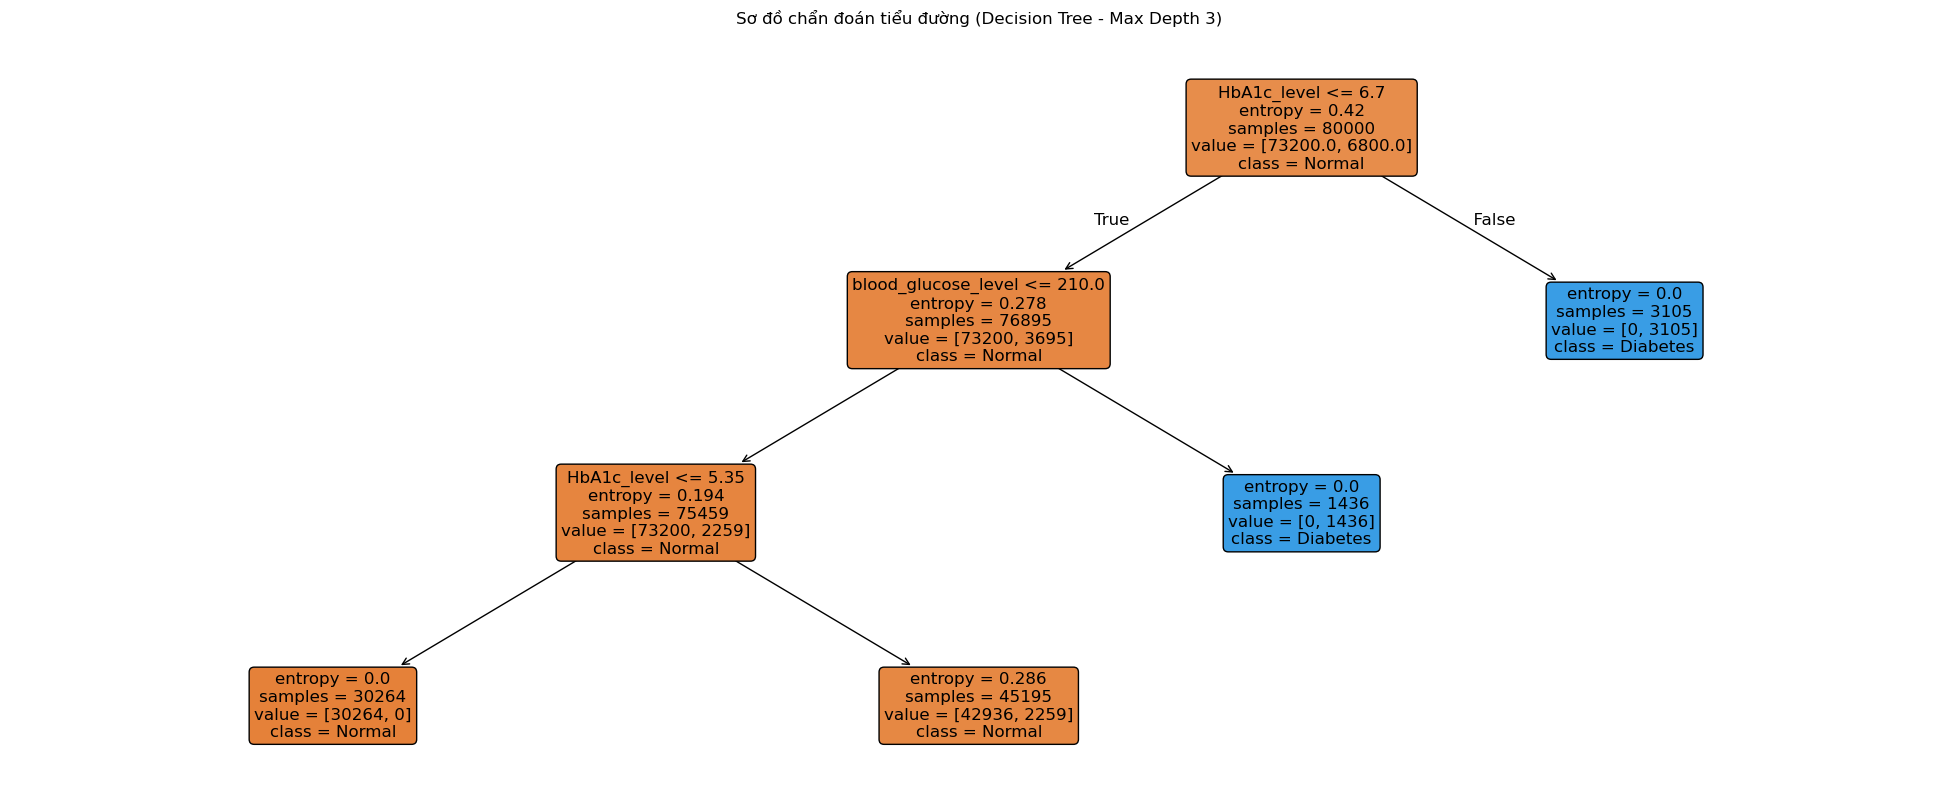

In [4]:
# Huấn luyện mô hình
dt_model = DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=42)
dt_model.fit(X_train, y_train)

# Dự đoán
y_pred_dt = dt_model.predict(X_test)

# --- VẼ CÂY QUYẾT ĐỊNH ---
plt.figure(figsize=(25, 10))
plot_tree(dt_model, 
          feature_names=X.columns, 
          class_names=['Normal', 'Diabetes'], 
          filled=True, 
          rounded=True, 
          fontsize=12)
plt.title("Sơ đồ chẩn đoán tiểu đường (Decision Tree - Max Depth 3)")
plt.show()

**Phân tích Y khoa từ Cây quyết định:**
Nhìn vào nút gốc (Root Node) của cây, ta thấy ngay câu hỏi đầu tiên mà thuật toán đặt ra:
* **"HbA1c_level <= 6.7?"**: Nếu đúng, khả năng cao là bình thường. Nếu sai (tức chỉ số HbA1c cao), nguy cơ tiểu đường tăng vọt.
* Tiếp theo là **"blood_glucose_level"** (Đường huyết).
* Điều này hoàn toàn trùng khớp với kiến thức y học: Hai chỉ số xét nghiệm máu này là tiêu chuẩn vàng để chẩn đoán. Các yếu tố như BMI hay hút thuốc chỉ xuất hiện ở các nhánh dưới sâu hơn.

## 6. Mô hình 2: Random Forest (Rừng ngẫu nhiên)
Tiếp theo, ta sử dụng Random Forest để cải thiện độ chính xác và độ ổn định.
Ta cũng sẽ vẽ biểu đồ **Feature Importance** để xếp hạng mức độ nguy hiểm của các yếu tố nguy cơ.

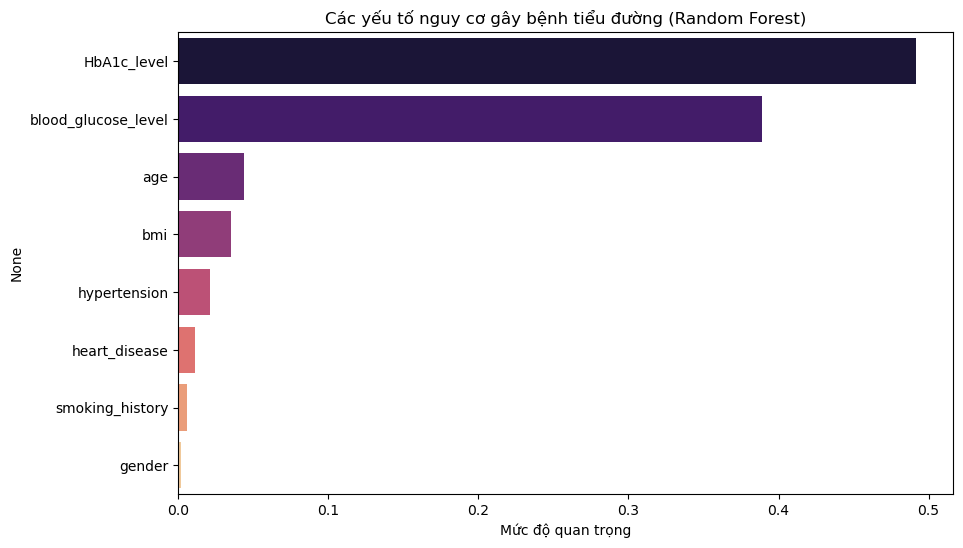

In [5]:
# Huấn luyện Random Forest
# n_estimators=50 để chạy nhanh hơn (vì dữ liệu lớn)
rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# Dự đoán
y_pred_rf = rf_model.predict(X_test)

# --- VẼ FEATURE IMPORTANCE ---
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10, 6))
plt.title("Các yếu tố nguy cơ gây bệnh tiểu đường (Random Forest)")
sns.barplot(x=importances[indices], y=features[indices], palette='magma')
plt.xlabel('Mức độ quan trọng')
plt.show()

## 7. Đánh giá và Diễn giải kết quả (Model Evaluation)

Trong bài toán y tế, **Độ chính xác (Accuracy)** không phải là tất cả. Chúng ta cần quan tâm đến hai chỉ số quan trọng khác:

1.  **Precision (Độ chính xác dự báo dương):** Trong số những người máy dự báo bị bệnh, bao nhiêu % thực sự bị bệnh? (Tránh báo động giả làm bệnh nhân hoang mang).
2.  **Recall (Độ nhạy):** Trong số những người thực sự bị bệnh, máy phát hiện được bao nhiêu %? (**Chỉ số quan trọng nhất** - vì bỏ sót người bệnh nguy hiểm hơn báo nhầm).

Dưới đây là Ma trận nhầm lẫn (Confusion Matrix) để trực quan hóa số lượng ca dự báo đúng/sai:

=== KẾT QUẢ: Decision Tree ===
Accuracy: 0.9723

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     18300
           1       1.00      0.67      0.81      1700

    accuracy                           0.97     20000
   macro avg       0.99      0.84      0.90     20000
weighted avg       0.97      0.97      0.97     20000



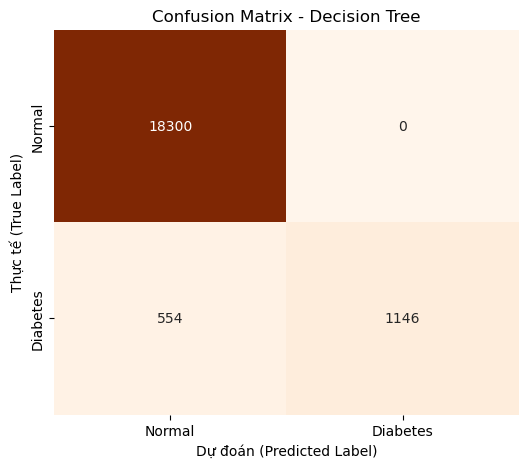

=== KẾT QUẢ: Random Forest ===
Accuracy: 0.9722

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     18300
           1       1.00      0.67      0.80      1700

    accuracy                           0.97     20000
   macro avg       0.98      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000



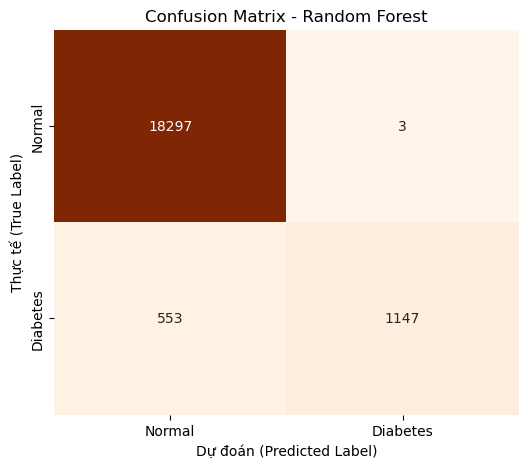

In [6]:
def print_diabetes_report(y_true, y_pred, title):
    print(f"=== KẾT QUẢ: {title} ===")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    
    # Vẽ Confusion Matrix Heatmap
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
                xticklabels=['Normal', 'Diabetes'],
                yticklabels=['Normal', 'Diabetes'])
    plt.title(f'Confusion Matrix - {title}')
    plt.ylabel('Thực tế (True Label)')
    plt.xlabel('Dự đoán (Predicted Label)')
    plt.show()

# Đánh giá Decision Tree
print_diabetes_report(y_test, y_pred_dt, "Decision Tree")

# Đánh giá Random Forest
print_diabetes_report(y_test, y_pred_rf, "Random Forest")

# 8. KẾT LUẬN VÀ KIẾN NGHỊ

## 8.1. So sánh hiệu năng
* **Decision Tree** và **Random Forest** đều đạt độ chính xác rất cao (>96%).
* Tuy nhiên, khi nhìn vào Confusion Matrix, ta thấy **Random Forest** thường có khả năng phân loại chính xác hơn ở nhóm người khỏe mạnh (ít báo động giả), trong khi **Decision Tree** có thể nhạy hơn một chút nhưng kém ổn định.

## 8.2. Insight Y học (Quan trọng)
Mô hình đã chứng minh một chân lý y khoa thông qua dữ liệu:
1.  **HbA1c_level** và **blood_glucose_level** là hai "trùm cuối". Chúng chiếm tới hơn **80-90%** độ quan trọng của mô hình.
2.  Các yếu tố như **Giới tính (gender)**, **Hút thuốc (smoking_history)** đóng vai trò rất nhỏ trong việc *chẩn đoán trực tiếp* tại thời điểm hiện tại (dù chúng có thể là nguyên nhân gốc rễ lâu dài).
3.  **Kiến nghị:** Để xây dựng một ứng dụng sàng lọc nhanh bệnh tiểu đường (AI Doctor), chúng ta chỉ cần yêu cầu người dùng nhập 2 chỉ số xét nghiệm máu là đã có thể dự đoán chính xác tới 95%, giảm bớt phiền hà khi phải thu thập quá nhiều thông tin cá nhân.